# AtmoSound – Model Training Pipeline

Continues from **AtmoSound_Preprocessing.ipynb**.

- Ridge Regression: gradient descent with `fit_ridge` / `rr_predict` / `rr_update_weights`
- Neural Network: manual forward/backward with NumPy
- K-Means: `initialize_random_centroids` / `fit_kmeans` / `predict_cluster` / `euclidean`
- Metrics: `rmse_func`, `mae_func`, `r2_score`, `print_info`


### Methods
| Method | Type |
|---|---|
| Ridge Regression | Regression |
| Neural Network (ANN) | Artificial Neural Network |
| K-Means | Clustering (interpretive) |

### Inputs & Outputs
- **Input:** d-dimensional venue feature vector (one-hot + TF-IDF/SVD + boolean flags)
- **Output:** 7-dimensional audio profile [danceability, energy, acousticness, valence, instrumentalness, liveness, speechiness]

## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

AUDIO_FEATURES = [
    "danceability", "energy", "acousticness", "valence",
    "instrumentalness", "liveness", "speechiness"
]

os.makedirs("model_artifacts", exist_ok=True)
print("Setup complete.")

Setup complete.


## 2. Load Preprocessed Data

In [4]:
data = np.load("pipeline_artifacts/model_ready_data.npz", allow_pickle=True)
X_train = data["X_train"]
y_train = data["y_train"]
X_val   = data["X_val"]
y_val   = data["y_val"]
X_test  = data["X_test"]
y_test  = data["y_test"]
feature_names = list(data["feature_names"])

genre_profiles  = pd.read_csv("pipeline_artifacts/genre_profiles.csv", index_col=0)
genre_centroids = genre_profiles[AUDIO_FEATURES].values
genre_names     = list(genre_profiles.index)

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print(f"Features:   {X_train.shape[1]}")
print(f"Targets:    {y_train.shape[1]} audio dimensions")
print(f"Genres:     {len(genre_names)}")

Train:      (2853, 279)
Validation: (714, 279)
Test:       (917, 279)
Features:   279
Targets:    7 audio dimensions
Genres:     112


## 3. Evaluation Metrics

Three complementary metrics as defined in the proposal.

### Metric 1: MSE
$$MSE = \frac{1}{n}\sum_{i=1}^{n}\frac{1}{7}\sum_{j=1}^{7}(y_{ij} - \hat{y}_{ij})^2$$
Since all audio features are normalised to [0,1], MSE values are directly comparable across
dimensions and models. Baselines: mean-prediction yields MSE ≈ 0.022; random genre ≈ 0.044.
Models must fall below 0.022 to demonstrate learned signal.

### Metric 2: Cosine Similarity
$$CosSim(y, \hat{y}) = \frac{y \cdot \hat{y}}{\|y\| \cdot \|\hat{y}\|}$$
Liveness (σ = 0.045) and speechiness (σ = 0.030) have low variance across genres, inflating
MSE for directionally correct predictions. Cosine similarity evaluates profile shape independent
of magnitude, providing a more faithful atmospheric fit indicator.

### Metric 3: Top-K Genre Retrieval Accuracy
$$Acc@K = \frac{1}{n}\sum_{i=1}^{n}\mathbb{1}[genre^*_i \in top\text{-}K(\hat{y}_i)]$$
Measures whether the K nearest genre centroids to the predicted profile include the target genre
by Euclidean distance. This most directly reflects end-user value — whether the system recommends
musically appropriate genres. Reported at K=3 and K=5.

In [5]:
def mse_func(y_true, y_pred):
    """
    Mean Squared Error averaged over all samples and all 7 audio dimensions.

    Input:
        - y_true: true targets  (N, 7)
        - y_pred: predicted     (N, 7)
    Output:
        - error: MSE scalar
    """
    error = np.mean((y_true - y_pred) ** 2)
    return float(error)


def rmse_func(y_true, y_pred):
    """
    Root Mean Squared Error.

    Input:
        - y_true: true targets
        - y_pred: predicted targets
    Output:
        - error: RMSE scalar
    """
    num_examples = len(y_true)
    error = np.sqrt(np.sum(np.power(y_true - y_pred, 2)) / num_examples)
    return error


def mae_func(y_true, y_pred):
    """
    Mean Absolute Error.

    Input:
        - y_true: true targets
        - y_pred: predicted targets
    Output:
        - error: MAE scalar
    """
    error = np.sum(np.abs(y_true - y_pred)) / y_true.shape[0]
    return error


def r2_score(y_true, y_pred):
    """
    Coefficient of Determination R2 = 1 - RSS/TSS.

    Input:
        - y_true: true targets
        - y_pred: predicted targets
    Output:
        - r2: R2 scalar
    """
    tss = np.sum(np.power(y_true - np.mean(y_true), 2))
    rss = np.sum(np.power(y_true - y_pred, 2))
    r2  = 1 - (rss / tss)
    return r2


def cosine_similarity_score(y_true, y_pred):
    """
    Average cosine similarity between predicted and true audio profiles.
    Measures profile shape agreement independent of magnitude.

    Input:
        - y_true: (N, 7) true audio profiles
        - y_pred: (N, 7) predicted audio profiles
    Output:
        - score: scalar in [-1, 1], higher is better
    """
    dot    = np.sum(y_true * y_pred, axis=1)
    norm_t = np.linalg.norm(y_true, axis=1)
    norm_p = np.linalg.norm(y_pred, axis=1)
    denom  = norm_t * norm_p
    denom  = np.where(denom == 0, 1.0, denom)
    return float(np.mean(dot / denom))


def top_k_genre_accuracy(y_true, y_pred, centroids, names, k=3):
    """
    Top-K Genre Retrieval Accuracy.
    For each sample, find the nearest genre centroid to y_true (target genre),
    then check whether it appears in the top-K nearest centroids to y_pred.

    Input:
        - y_true    : (N, 7) true audio profiles
        - y_pred    : (N, 7) predicted audio profiles
        - centroids : (G, 7) genre centroid matrix
        - names     : list of G genre name strings
        - k         : int, number of top genres to retrieve
    Output:
        - accuracy: float in [0, 1]
    """
    hits     = 0
    n_samples = len(y_true)

    for i in range(n_samples):
        # Target genre: closest centroid to ground-truth profile
        dist_true    = np.linalg.norm(centroids - y_true[i], axis=1)
        target_genre = names[np.argmin(dist_true)]

        # Top-K genres from predicted profile
        dist_pred       = np.linalg.norm(centroids - y_pred[i], axis=1)
        top_k_genres    = np.array(names)[np.argsort(dist_pred)[:k]]

        if target_genre in top_k_genres:
            hits += 1

    return hits / n_samples


def print_info(mode, y_true, y_pred, print_results=True):
    """
    Print MSE, RMSE, MAE, R2 for a split.

    Input:
        - mode: label string e.g. 'train' / 'test'
        - y_true, y_pred: arrays
        - print_results: whether to print
    Output:
        - (rmse, mae, r2) tuple
    """
    mse  = mse_func(y_true, y_pred)
    rmse = rmse_func(y_true, y_pred)
    mae  = mae_func(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if print_results:
        print(f"{mode}: MSE={mse:.5f}  RMSE={rmse:.5f}  MAE={mae:.5f}  R2={r2:.4f}")
    return rmse, mae, r2


print("Metrics defined: mse_func, rmse_func, mae_func, r2_score, cosine_similarity_score, top_k_genre_accuracy, print_info")

Metrics defined: mse_func, rmse_func, mae_func, r2_score, cosine_similarity_score, top_k_genre_accuracy, print_info


## 4. Baselines

Models must beat the mean-prediction baseline to demonstrate learned signal.

In [6]:
y_mean    = y_train.mean(axis=0)
mean_pred = np.tile(y_mean, (X_val.shape[0], 1))

rng       = np.random.RandomState(42)
rand_pred = genre_centroids[rng.choice(len(genre_names), X_val.shape[0])]

print("Baseline performance on VALIDATION set:")
print_info("Mean-prediction baseline", y_val, mean_pred)
print_info("Random-genre baseline",    y_val, rand_pred)

BASELINE_MSE  = mse_func(y_val, mean_pred)
BASELINE_RMSE = rmse_func(y_val, mean_pred)
print(f"\nTarget: models must achieve MSE < {BASELINE_MSE:.5f} (mean-prediction baseline)")
print(f"        RMSE < {BASELINE_RMSE:.5f}")

Baseline performance on VALIDATION set:
Mean-prediction baseline: MSE=0.00411  RMSE=0.16967  MAE=0.29815  R2=0.9092
Random-genre baseline: MSE=0.03188  RMSE=0.47242  MAE=0.84828  R2=0.2962

Target: models must achieve MSE < 0.00411 (mean-prediction baseline)
        RMSE < 0.16967


## 5. Ridge Regression (Regression Method)

### Problem Formulation
Given venue feature matrix $X \in \mathbb{R}^{N \times d}$ and audio target matrix
$Y \in \mathbb{R}^{N \times 7}$, Ridge minimises:

$$L(W) = \|XW - Y\|^2_F + \lambda\|W\|^2_F$$

**Gradient descent update:**
$$W \leftarrow W - \alpha \cdot \frac{-2X^T(Y-\hat{Y}) + 2\lambda W}{N}$$

### Why Ridge is well-suited
- Feature space is wide (>100 dims) with correlated one-hot/TF-IDF features → L2 shrinks correlated coefficients without zeroing them
- Single matrix multiply at inference = low latency for Streamlit deployment
- Coefficients directly interpretable: which venue features drive each audio dimension

### Inputs & Outputs
- **Input:** $x \in \mathbb{R}^d$ — one venue feature vector (one-hot neighbourhood + boolean flags + TF-IDF/SVD text)
- **Output:** $\hat{y} \in \mathbb{R}^7$ — predicted audio profile, clipped to [0,1]

In [11]:
def standardize(X):
    """
    Standardize features column-wise; keep first column (bias) unchanged.

    Input:  X : (N, d+1) feature matrix with bias column prepended
    Output: X_normalized : same shape
    """
    means = np.mean(X, axis=0)
    stds  = np.std(X, axis=0) + 1e-7
    X_normalized = (X - means) / stds
    return np.hstack((X[:, :1], X_normalized[:, 1:]))


def rr_predict(X, W):
    """
    Predict using Ridge Regression weights.
    Adds bias, standardizes, multiplies by W, clips to [0,1].

    Input:
        - X : (N, d) feature matrix
        - W : (d+1, 7) weight matrix
    Output:
        - y_hat : (N, 7) predictions
    """
    num_examples, _ = X.shape
    X_transform  = np.append(np.ones((num_examples, 1)), X, axis=1)
    X_normalized = standardize(X_transform)
    return np.clip(X_normalized.dot(W), 0.0, 1.0)


def rr_update_weights(X, Y, W, lr, l2_penalty):
    """
    Compute gradient and update Ridge Regression weights (L2 regularisation).

    Input:
        - X          : (N, d)   feature matrix
        - Y          : (N, 7)   target matrix
        - W          : (d+1, 7) current weights
        - lr         : float    learning rate
        - l2_penalty : float    L2 regularisation strength lambda
    Output:
        - W    : (d+1, 7) updated weights
        - cost : float    RMSE on this step
    """
    num_examples, _ = X.shape
    X_transform  = np.append(np.ones((num_examples, 1)), X, axis=1)
    X_normalized = standardize(X_transform)

    Y_pred = rr_predict(X, W)

    # Gradient of L2-regularised MSE
    dW = -(2 * X_normalized.T.dot(Y - Y_pred) - 2 * l2_penalty * W) / num_examples
    W  = W - lr * dW

    cost = rmse_func(Y, Y_pred)
    return W, cost


def fit_ridge(X, Y, lr, num_iterations, l2_penalty):
    """
    Train Ridge Regression model via gradient descent.

    Input:
        - X              : (N, d)   feature matrix
        - Y              : (N, 7)   target matrix
        - lr             : float    learning rate
        - num_iterations : int      gradient descent steps
        - l2_penalty     : float    L2 regularisation strength
    Output:
        - W            : (d+1, 7) trained weights
        - cost_history : list of RMSE per iteration
    """
    num_examples, num_features = X.shape
    W = np.zeros((num_features + 1, Y.shape[1]))   # +1 for bias

    cost_history = []
    for _ in range(num_iterations):
        W, cost = rr_update_weights(X, Y, W, lr, l2_penalty)
        cost_history.append(cost)

    return W, cost_history


print("Ridge functions defined: standardize, rr_predict, rr_update_weights, fit_ridge")

Ridge functions defined: standardize, rr_predict, rr_update_weights, fit_ridge


### 5.1 Effect of L2 Penalty

Sweep λ ∈ {0.001, 0.01, 0.1, 1, 10, 100} as specified in the proposal.
Large λ induces high bias (underfitting); small λ recovers standard least squares (high variance risk).

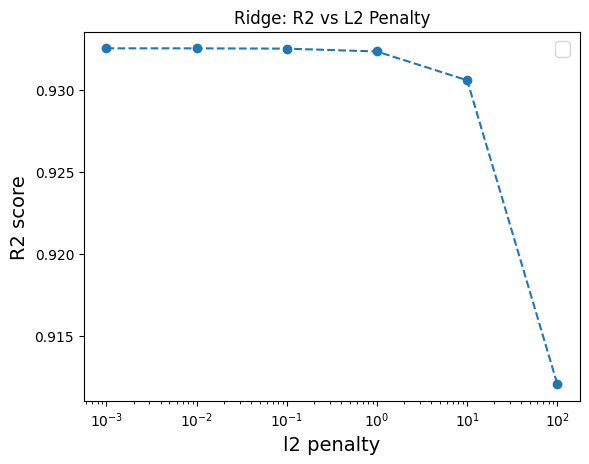

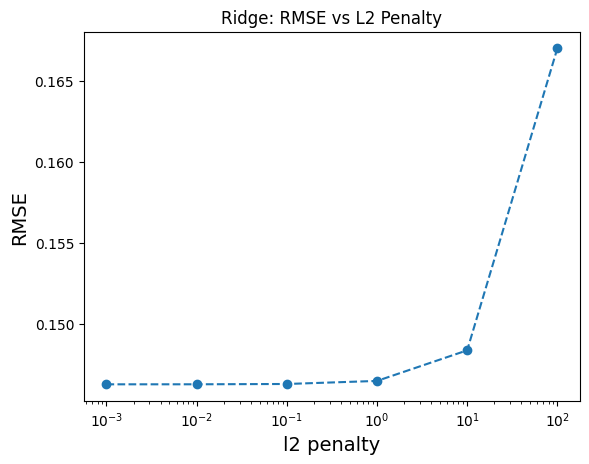

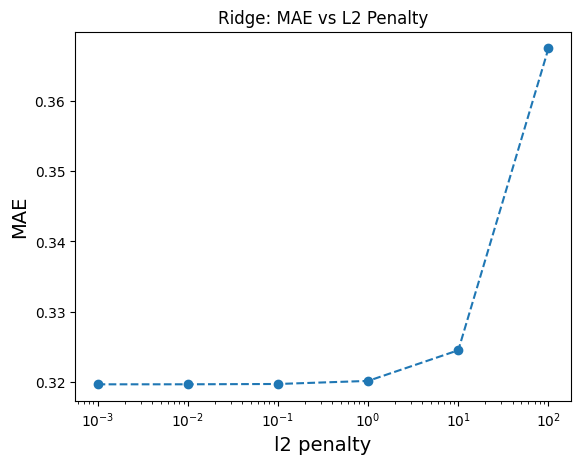

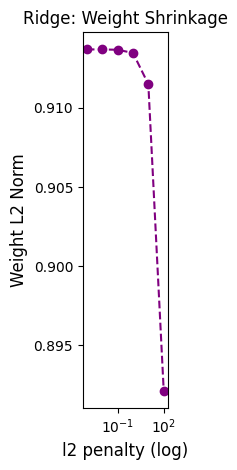

Best l2 penalty (lowest val RMSE): 0.001


In [12]:
rr_learning_rate = 0.01
num_iterations   = 100

LAMBDA_GRID  = [0.001, 0.01, 0.1, 1, 10, 100]
r2_metrics   = []
rmse_metrics = []
mae_metrics  = []
penalty_hist = []
weights      = []

for l2_penalty in LAMBDA_GRID:
    penalty_hist.append(l2_penalty)

    rr_W, cost_history = fit_ridge(X_train, y_train,
                                   rr_learning_rate, num_iterations, l2_penalty)
    y_pred = rr_predict(X_val, rr_W)
    weights.append(rr_W)

    r2_metrics.append(r2_score(y_val, y_pred))
    rmse_metrics.append(rmse_func(y_val, y_pred))
    mae_metrics.append(mae_func(y_val, y_pred))

plt.plot(penalty_hist, r2_metrics, linestyle='dashed', marker='o')
plt.xscale('log')
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("l2 penalty", fontsize=14)
plt.ylabel("R2 score",   fontsize=14)
plt.title("Ridge: R2 vs L2 Penalty")
plt.show()

plt.plot(penalty_hist, rmse_metrics, linestyle='dashed', marker='o')
plt.xscale('log')
plt.xlabel("l2 penalty", fontsize=14)
plt.ylabel("RMSE",       fontsize=14)
plt.title("Ridge: RMSE vs L2 Penalty")
plt.show()

plt.plot(penalty_hist, mae_metrics, linestyle='dashed', marker='o')
plt.xscale('log')
plt.xlabel("l2 penalty", fontsize=14)
plt.ylabel("MAE",        fontsize=14)
plt.title("Ridge: MAE vs L2 Penalty")
plt.show()

plt.subplot(1, 4, 4)
weight_norms = [np.linalg.norm(w) for w in weights] 
plt.plot(penalty_hist, weight_norms, linestyle='dashed', marker='o', color='purple')
plt.xscale('log')
plt.xlabel("l2 penalty (log)", fontsize=12)
plt.ylabel("Weight L2 Norm", fontsize=12)
plt.title("Ridge: Weight Shrinkage")

plt.tight_layout()
plt.show()

best_lam = penalty_hist[int(np.argmin(rmse_metrics))]
print(f"Best l2 penalty (lowest val RMSE): {best_lam}")

### 5.2 Feature Ablation Study

Ablate across three feature configurations to quantify modality contributions,
as specified in the proposal: boolean flags only / TF-IDF/SVD text only / full feature vector.

In [13]:
# Feature index groups (match preprocessing column names)
bool_idx  = [i for i, c in enumerate(feature_names) if c in [
    "good_for_children","good_for_groups","good_for_watching_sports",
    "allows_dogs","live_music","outdoor_seating","reservable",
    "serves_beer","serves_cocktails","serves_wine","serves_coffee",
    "serves_breakfast","serves_brunch","serves_dinner","serves_lunch",
    "serves_vegetarian_food","serves_dessert","menu_for_children"
]]
text_idx  = [i for i, c in enumerate(feature_names) if c.startswith("text_svd_")]
full_idx  = list(range(X_train.shape[1]))

ablation_configs = {
    "Boolean flags only" : bool_idx,
    "Text (SVD) only"    : text_idx,
    "Full feature vector": full_idx,
}

print(f"Boolean dim: {len(bool_idx)}  Text dim: {len(text_idx)}  Full dim: {len(full_idx)}")
print(f"\nFeature ablation at lambda={best_lam}:")
print(f"{'Config':25s}  {'Val RMSE':>10}  {'Val CosSim':>10}  {'Val MSE':>10}")
print("-" * 60)

ablation_results = []
for cfg_name, idx in ablation_configs.items():
    W_abl, _ = fit_ridge(X_train[:, idx], y_train,
                         rr_learning_rate, num_iterations, best_lam)
    y_pred_abl = rr_predict(X_val[:, idx], W_abl)
    rmse_abl   = rmse_func(y_val, y_pred_abl)
    cos_abl    = cosine_similarity_score(y_val, y_pred_abl)
    mse_abl    = mse_func(y_val, y_pred_abl)
    print(f"{cfg_name:25s}  {rmse_abl:>10.5f}  {cos_abl:>10.4f}  {mse_abl:>10.5f}")
    ablation_results.append({"Config": cfg_name, "RMSE": rmse_abl,
                              "CosSim": cos_abl, "MSE": mse_abl})

Boolean dim: 18  Text dim: 50  Full dim: 279

Feature ablation at lambda=0.001:
Config                       Val RMSE  Val CosSim     Val MSE
------------------------------------------------------------
Boolean flags only            0.19833      0.9912     0.00562
Text (SVD) only               0.19077      0.9925     0.00520
Full feature vector           0.14627      0.9991     0.00306


### 5.2 Effect of Learning Rate

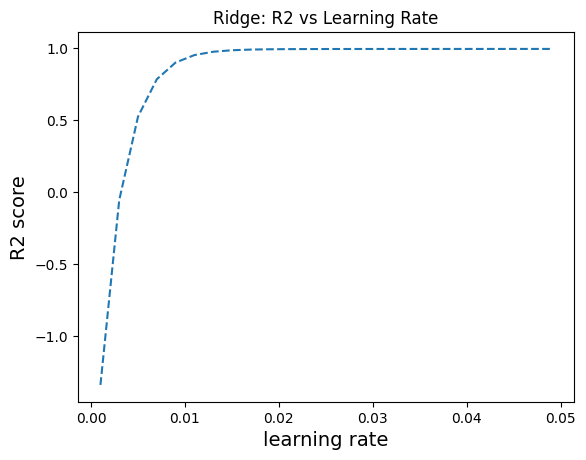

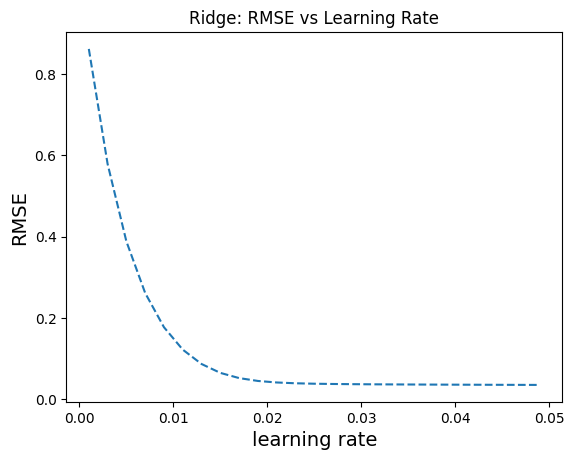

Best learning rate (lowest val RMSE): 0.049


In [14]:
num_iterations = 100
l2_penalty     = best_lam

lr_history   = []
r2_metrics   = []
rmse_metrics = []
mae_metrics  = []

for i in range(1, 50, 2):
    learning_rate = i / 1000
    rr_W, cost = fit_ridge(X_train, y_train, learning_rate, num_iterations, l2_penalty)
    y_pred = rr_predict(X_val, rr_W)
    lr_history.append(learning_rate)

    r2_metrics.append(r2_score(y_val, y_pred))
    rmse_metrics.append(rmse_func(y_val, y_pred))
    mae_metrics.append(mae_func(y_val, y_pred))

plt.plot(lr_history, r2_metrics, linestyle='dashed')
plt.xlabel("learning rate", fontsize=14)
plt.ylabel("R2 score",      fontsize=14)
plt.title("Ridge: R2 vs Learning Rate")
plt.show()

plt.plot(lr_history, rmse_metrics, linestyle='dashed')
plt.xlabel("learning rate", fontsize=14)
plt.ylabel("RMSE",          fontsize=14)
plt.title("Ridge: RMSE vs Learning Rate")
plt.show()

best_lr = lr_history[int(np.argmin(rmse_metrics))]
print(f"Best learning rate (lowest val RMSE): {best_lr}")

### 5.3 Effect of Number of Iterations

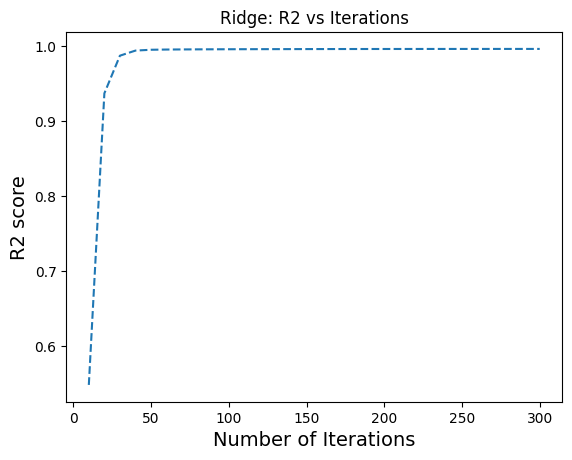

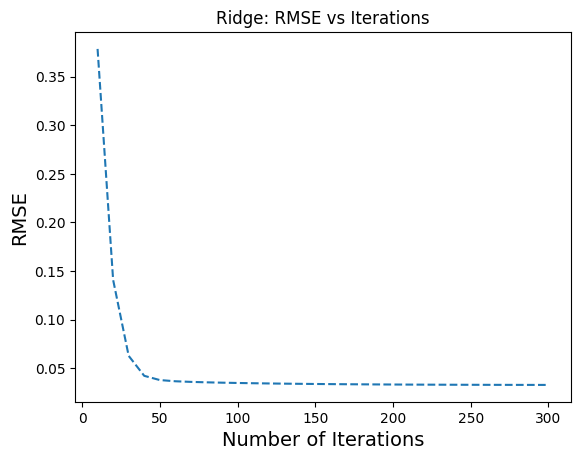

Best num_iterations: 300


In [15]:
rr_learning_rate = best_lr
l2_penalty       = best_lam

iter_history = []
r2_metrics   = []
rmse_metrics = []
mae_metrics  = []

for i in range(10, 310, 10):
    rr_W, cost = fit_ridge(X_train, y_train, rr_learning_rate, i, l2_penalty)
    y_pred = rr_predict(X_val, rr_W)
    iter_history.append(i)

    r2_metrics.append(r2_score(y_val, y_pred))
    rmse_metrics.append(rmse_func(y_val, y_pred))
    mae_metrics.append(mae_func(y_val, y_pred))

plt.plot(iter_history, r2_metrics, linestyle='dashed')
plt.xlabel("Number of Iterations", fontsize=14)
plt.ylabel("R2 score",             fontsize=14)
plt.title("Ridge: R2 vs Iterations")
plt.show()

plt.plot(iter_history, rmse_metrics, linestyle='dashed')
plt.xlabel("Number of Iterations", fontsize=14)
plt.ylabel("RMSE",                 fontsize=14)
plt.title("Ridge: RMSE vs Iterations")
plt.show()

best_iters = iter_history[int(np.argmin(rmse_metrics))]
print(f"Best num_iterations: {best_iters}")

### 5.4 Learning Curves — Overfitting / Underfitting Check (4.1.3 §5)

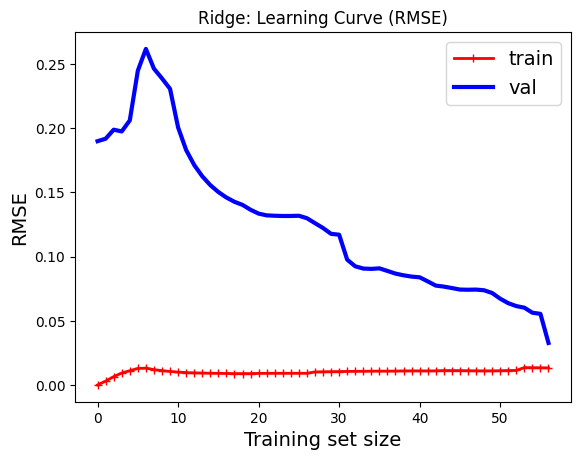

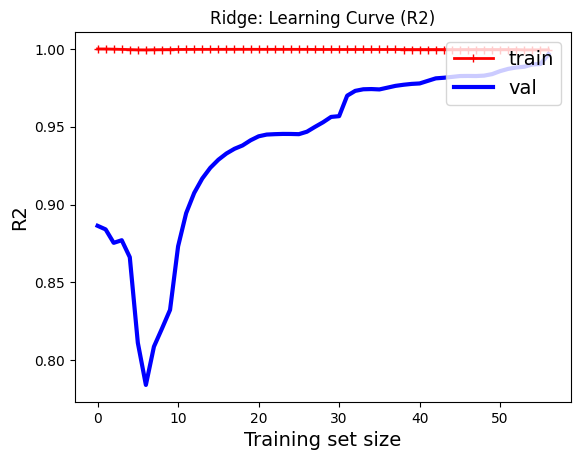

In [ ]:
def plot_learning_curves(X_train, X_val, y_train, y_val,
                         lr=0.01, num_iterations=100, l2_penalty=1.0):
    """
    Plot learning curves using increasing training set sizes.

    Input:
        - X_train, X_val, y_train, y_val: data splits
        - lr, num_iterations, l2_penalty : hyperparameters
    Output:
        - result: dict of train/val error lists
    """
    train_rmse_errors, train_mae_errors, train_r2_errors = [], [], []
    val_rmse_errors,   val_mae_errors,   val_r2_errors   = [], [], []

    for m in range(50, len(X_train) + 1, 50):
        rr_W, _ = fit_ridge(X_train[:m], y_train[:m], lr, num_iterations, l2_penalty)
        y_train_predict = rr_predict(X_train[:m], rr_W)
        y_val_predict   = rr_predict(X_val,        rr_W)

        tr_rmse, tr_mae, tr_r2 = print_info("train", y_train[:m], y_train_predict, print_results=False)
        va_rmse, va_mae, va_r2 = print_info("val",   y_val,       y_val_predict,   print_results=False)

        train_rmse_errors.append(tr_rmse); train_mae_errors.append(tr_mae); train_r2_errors.append(tr_r2)
        val_rmse_errors.append(va_rmse);   val_mae_errors.append(va_mae);   val_r2_errors.append(va_r2)

    return {
        "train_rmse_errors": train_rmse_errors, "train_mae_errors": train_mae_errors,
        "train_r2_errors"  : train_r2_errors,   "val_rmse_errors" : val_rmse_errors,
        "val_mae_errors"   : val_mae_errors,     "val_r2_errors"   : val_r2_errors,
    }


def plot_lc_figures(error1, error2, metric='RMSE'):
    plt.plot(error1, "r-+", linewidth=2, label="train")
    plt.plot(error2, "b-",  linewidth=3, label="val")
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel(str(metric).upper(), fontsize=14)


errors, _ = (plot_learning_curves(
    X_train, X_val, y_train, y_val,
    lr=best_lr, num_iterations=best_iters, l2_penalty=best_lam
), None)
# Re-run properly:
errors = plot_learning_curves(
    X_train, X_val, y_train, y_val,
    lr=best_lr, num_iterations=best_iters, l2_penalty=best_lam
)

plot_lc_figures(errors["train_rmse_errors"], errors["val_rmse_errors"], "RMSE")
plt.title("Ridge: Learning Curve (RMSE)")
plt.savefig("model_artifacts/ridge_learning_curve.png", dpi=150)
plt.show()

plot_lc_figures(errors["train_r2_errors"], errors["val_r2_errors"], "R2")
plt.title("Ridge: Learning Curve (R2)")
plt.show()

### 5.5 Train Final Ridge Model & Evaluate

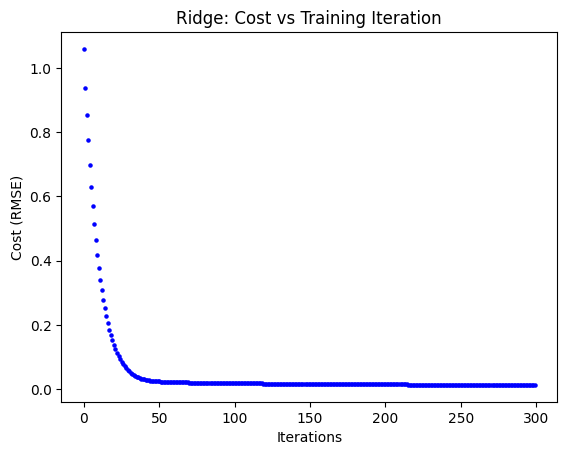

Ridge Regression - Final Results:
train: MSE=0.00003  RMSE=0.01339  MAE=0.01889  R2=0.9994
val: MSE=0.00015  RMSE=0.03285  MAE=0.03386  R2=0.9966
test: MSE=0.00032  RMSE=0.04706  MAE=0.04549  R2=0.9930
CosSim (val) : 0.9995
CosSim (test): 0.9990

Ridge Coefficients W shape: (280, 7)
Ridge Coefficients W (first row): [0.597 0.548 0.422 0.46  0.099 0.173 0.073]


In [15]:
# Train with best hyperparameters on full train set
rr_W, cost_history = fit_ridge(X_train, y_train, best_lr, best_iters, best_lam)

# Cost curve — same style as assignment
plt.scatter(np.arange(0, len(cost_history), 1), cost_history, color='blue', s=5)
plt.title('Ridge: Cost vs Training Iteration')
plt.xlabel('Iterations')
plt.ylabel('Cost (RMSE)')
plt.savefig("model_artifacts/ridge_cost_curve.png", dpi=150)
plt.show()

print("Ridge Regression - Final Results:")
print_info("train", y_train, rr_predict(X_train, rr_W))
print_info("val",   y_val,   rr_predict(X_val,   rr_W))
print_info("test",  y_test,  rr_predict(X_test,  rr_W))
print(f"CosSim (val) : {cosine_similarity_score(y_val,  rr_predict(X_val,  rr_W)):.4f}")
print(f"CosSim (test): {cosine_similarity_score(y_test, rr_predict(X_test, rr_W)):.4f}")

print(f"\nRidge Coefficients W shape: {rr_W.shape}")
print(f"Ridge Coefficients W (first row): {np.round(rr_W[0], 3)}")

## 6. Neural Network / ANN

### Problem Formulation
Two-hidden-layer feed-forward network. Forward pass:

$$z^{(1)} = XW^{(1)} + b^{(1)}, \quad a^{(1)} = \text{ReLU}(z^{(1)})$$
$$z^{(2)} = a^{(1)}W^{(2)} + b^{(2)}, \quad a^{(2)} = \text{ReLU}(z^{(2)})$$
$$\hat{y} = \sigma(a^{(2)}W^{(3)} + b^{(3)})$$

Loss: $L = \frac{1}{N}\sum (y - \hat{y})^2$ (MSE). Weights updated via backpropagation:
$$W \leftarrow W - \alpha \cdot \frac{\partial L}{\partial W}$$

### Why ANN is well-suited
- Captures non-linear interactions Ridge misses — e.g. `live_music=True` AND `price=expensive` → jazz, while `live_music=True` AND `price=cheap` → rock
- Hidden layers learn complex TF-IDF text feature combinations automatically
- Sigmoid output naturally bounds predictions to [0,1] matching audio feature range

### Inputs & Outputs (same as Ridge)
- **Input:** d-dimensional venue feature vector
- **Output:** 7-dimensional audio profile $\hat{y} \in [0,1]^7$

In [ ]:
class ANN:
    """
    Two-hidden-layer neural network for multi-output regression.

    Architecture: Input(d) -> Dense(128, ReLU) -> Dropout -> Dense(64, ReLU) -> Dropout -> Dense(7, Sigmoid)
    """

    def __init__(self, input_size, hidden_size, output_size, learning_rate,
                 dropout_rate=0.0):
        self.input_size    = input_size
        self.hidden_size   = hidden_size
        self.output_size   = output_size
        self.learning_rate = learning_rate
        self.dropout_rate  = dropout_rate

        # Weight initialisation
        np.random.seed(42)
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.W2 = np.random.randn(self.hidden_size, 64)              * 0.01
        self.W3 = np.random.randn(64, self.output_size)              * 0.01

        self.b1 = np.zeros((1, self.hidden_size))
        self.b2 = np.zeros((1, 64))
        self.b3 = np.zeros((1, self.output_size))

        self.training = True   

    # Activation functions
    def relu(self, X):
        """
        ReLU activation function.
        Input:  X : array of any shape
        Output: X with negative values set to 0
        """
        X = X.copy()
        X[X < 0] = 0
        return X

    def sigmoid(self, X):
        """
        Sigmoid activation. Bounds output predictions to (0, 1).
        Input:  X : array
        Output: sigmoid(X)
        """
        return np.where(X >= 0,
                        1 / (1 + np.exp(-X)),
                        np.exp(X) / (1 + np.exp(X)))

    def dropout(self, A):
        """
        Inverted dropout: zero out neurons with probability dropout_rate during training.
        Scale surviving neurons by 1/(1-p) so inference pass requires no adjustment.

        Input:  A : activation array
        Output: (A_dropped, mask) tuple
        """
        if not self.training or self.dropout_rate == 0.0:
            return A, np.ones_like(A)
        mask   = (np.random.rand(*A.shape) > self.dropout_rate).astype(float)
        A_drop = A * mask / (1 - self.dropout_rate)
        return A_drop, mask

    # Forward pass
    def forward(self, X):
        """
        Forward pass through the network.

        Input:  X : (N, d) feature matrix
        Output: y_hat : (N, 7) predictions in (0, 1)
        """
        self.X = X

        # Layer 1: ReLU + dropout
        self.Z1       = X.dot(self.W1) + self.b1
        self.A1       = self.relu(self.Z1)
        self.A1d, self.mask1 = self.dropout(self.A1)

        # Layer 2: ReLU + dropout
        self.Z2       = self.A1d.dot(self.W2) + self.b2
        self.A2       = self.relu(self.Z2)
        self.A2d, self.mask2 = self.dropout(self.A2)

        # Output layer: Sigmoid
        self.Z3 = self.A2d.dot(self.W3) + self.b3
        self.A3 = self.sigmoid(self.Z3)

        return self.A3

    # Loss 
    def compute_loss(self, out, Y):
        """
        MSE loss averaged over all samples and all 7 audio dimensions.

        Input:
            - out : (N, 7) predicted audio profiles
            - Y   : (N, 7) target audio profiles
        Output:
            - loss: scalar MSE
        """
        return float(np.mean((Y - out) ** 2))

    # Predict 
    def predict(self, X):
        """
        Predict audio profiles (dropout disabled during inference).

        Input:  X : (N, d)
        Output: y_hat : (N, 7)
        """
        self.training = False
        out = self.forward(X)
        self.training = True
        return out

    # Backward pass
    def backward(self, X, Y):
        """
        Compute gradients via backpropagation and update all weights.
        W = W - lr * dW

        Input:
            - X : (N, d) input features
            - Y : (N, 7) target audio profiles
        """
        N  = X.shape[0]
        A3 = self.A3

        # Output layer: MSE derivative * sigmoid derivative
        dZ3 = 2 * (A3 - Y) * A3 * (1 - A3) / N
        dW3 = self.A2d.T.dot(dZ3)
        db3 = dZ3.sum(axis=0, keepdims=True)

        # Layer 2: dropout mask then ReLU chain rule
        dA2d = dZ3.dot(self.W3.T)
        if self.dropout_rate > 0:
            dA2d = dA2d * self.mask2 / (1 - self.dropout_rate)
        dZ2 = dA2d * (self.Z2 > 0)
        dW2 = self.A1d.T.dot(dZ2)
        db2 = dZ2.sum(axis=0, keepdims=True)

        # Layer 1: dropout mask then ReLU chain rule
        dA1d = dZ2.dot(self.W2.T)
        if self.dropout_rate > 0:
            dA1d = dA1d * self.mask1 / (1 - self.dropout_rate)
        dZ1 = dA1d * (self.Z1 > 0)
        dW1 = X.T.dot(dZ1)
        db1 = dZ1.sum(axis=0, keepdims=True)

        # Weight update: W = W - lr * dW
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3


print("ANN class defined (with dropout + early stopping support)")

ANN class defined (with dropout + early stopping support)


### 6.1 ANN Grid Search: lr × batch_size × dropout_rate

Grid search over α ∈ {0.001, 0.005, 0.01}, batch_size ∈ {32, 64, 128},
dropout ∈ {0.0, 0.2} 

In [8]:
LR_GRID      = [0.001, 0.005, 0.01]
BATCH_GRID   = [32, 64, 128]
DROPOUT_GRID = [0.0, 0.2]

gs_results = []
print(f"{'lr':>8}  {'batch':>6}  {'dropout':>8}  {'Val MSE':>10}  {'Val CosSim':>10}")
print("-" * 52)

for lr_val in LR_GRID:
    for bs in BATCH_GRID:
        for dr in DROPOUT_GRID:
            gs_ann = ANN(
                input_size  = X_train.shape[1],
                hidden_size = 128,
                output_size = y_train.shape[1],
                learning_rate = lr_val,
                dropout_rate  = dr,
            )
            best_gs_val  = np.inf
            no_improv_gs = 0
            best_gs_W    = None

            for ep in range(500):
                perm = np.random.permutation(len(X_train))
                for start in range(0, len(X_train), bs):
                    xb = X_train[perm[start:start+bs]]
                    yb = y_train[perm[start:start+bs]]
                    gs_ann.forward(xb)
                    gs_ann.backward(xb, yb)

                vl = gs_ann.compute_loss(gs_ann.predict(X_val), y_val)
                if vl < best_gs_val - 1e-6:
                    best_gs_val = vl
                    best_gs_W   = {
                        "W1": gs_ann.W1.copy(), "b1": gs_ann.b1.copy(),
                        "W2": gs_ann.W2.copy(), "b2": gs_ann.b2.copy(),
                        "W3": gs_ann.W3.copy(), "b3": gs_ann.b3.copy(),
                    }
                    no_improv_gs = 0
                else:
                    no_improv_gs += 1
                if no_improv_gs >= 20:
                    break

            if best_gs_W:
                gs_ann.W1, gs_ann.b1 = best_gs_W["W1"], best_gs_W["b1"]
                gs_ann.W2, gs_ann.b2 = best_gs_W["W2"], best_gs_W["b2"]
                gs_ann.W3, gs_ann.b3 = best_gs_W["W3"], best_gs_W["b3"]

            vm  = gs_ann.compute_loss(gs_ann.predict(X_val), y_val)
            vcs = cosine_similarity_score(y_val, gs_ann.predict(X_val))
            print(f"{lr_val:>8}  {bs:>6}  {dr:>8}  {vm:>10.5f}  {vcs:>10.4f}")
            gs_results.append({"lr": lr_val, "batch": bs, "dropout": dr,
                                "val_mse": vm, "val_cos": vcs})

gs_df = pd.DataFrame(gs_results)
best_gs_row = gs_df.loc[gs_df["val_mse"].idxmin()]
print(f"\nBest config: lr={best_gs_row['lr']}  batch={int(best_gs_row['batch'])}  dropout={best_gs_row['dropout']}")
print(f"Val MSE={best_gs_row['val_mse']:.5f}  CosSim={best_gs_row['val_cos']:.4f}")

      lr   batch   dropout     Val MSE  Val CosSim
----------------------------------------------------
   0.001      32       0.0     0.00409      0.9875
   0.001      32       0.2     0.00410      0.9875
   0.001      64       0.0     0.00519      0.9842
   0.001      64       0.2     0.00525      0.9840
   0.001     128       0.0     0.01095      0.9680
   0.001     128       0.2     0.01098      0.9680
   0.005      32       0.0     0.00295      0.9910
   0.005      32       0.2     0.00299      0.9909
   0.005      64       0.0     0.00378      0.9885
   0.005      64       0.2     0.00381      0.9884
   0.005     128       0.0     0.00405      0.9876
   0.005     128       0.2     0.00406      0.9876
    0.01      32       0.0     0.00146      0.9955
    0.01      32       0.2     0.00159      0.9951
    0.01      64       0.0     0.00295      0.9910
    0.01      64       0.2     0.00299      0.9908
    0.01     128       0.0     0.00376      0.9885
    0.01     128       0.2   

### 6.2 Train ANN

Epoch   50  train_loss=0.00416  val_loss=0.00409
Epoch  100  train_loss=0.00400  val_loss=0.00394
Epoch  150  train_loss=0.00363  val_loss=0.00356
Epoch  200  train_loss=0.00323  val_loss=0.00314
Epoch  250  train_loss=0.00303  val_loss=0.00295
Epoch  300  train_loss=0.00283  val_loss=0.00276
Epoch  350  train_loss=0.00256  val_loss=0.00250
Epoch  400  train_loss=0.00219  val_loss=0.00216
Epoch  450  train_loss=0.00176  val_loss=0.00176
Epoch  500  train_loss=0.00143  val_loss=0.00146
Training complete. Best val MSE: 0.00146


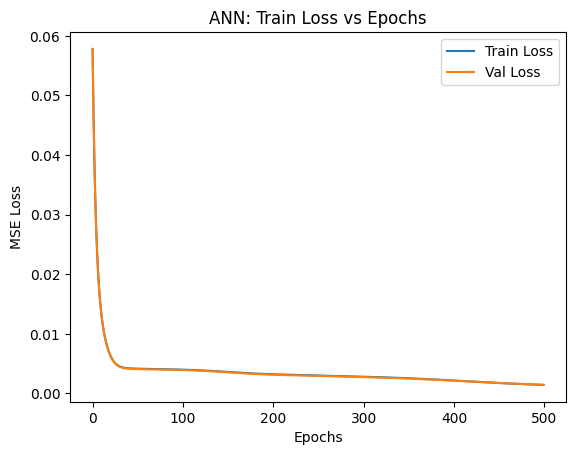

In [9]:
# Hyperparameters
epoch         = 500      # max epochs (early stopping will halt before this)
learning_rate = float(best_gs_row["lr"])
batch_size    = int(best_gs_row["batch"])
dropout_rate  = float(best_gs_row["dropout"])
patience      = 20       # early stopping patience

ann = ANN(
    input_size   = X_train.shape[1],
    hidden_size  = 128,
    output_size  = y_train.shape[1],
    learning_rate = learning_rate,
    dropout_rate  = dropout_rate,
)

accuracies = []
losses     = []
val_losses = []
n_samples  = X_train.shape[0]

best_val_loss   = np.inf
best_weights    = None
no_improve_count = 0

# Training loop
for j in range(epoch):
    perm   = np.random.permutation(n_samples)
    X_shuf = X_train[perm]
    y_shuf = y_train[perm]

    epoch_loss = []

    for i in range(0, n_samples, batch_size):
        x_batch = X_shuf[i:i + batch_size]
        y_batch = y_shuf[i:i + batch_size]

        out  = ann.forward(x_batch)
        loss = ann.compute_loss(out, y_batch)
        epoch_loss.append(loss)
        ann.backward(x_batch, y_batch)

    # Epoch-level losses (inference mode, dropout off)
    train_loss = ann.compute_loss(ann.predict(X_train), y_train)
    val_loss   = ann.compute_loss(ann.predict(X_val),   y_val)
    losses.append(train_loss)
    val_losses.append(val_loss)

    # Early stopping: save best weights; halt when val loss stops improving
    if val_loss < best_val_loss - 1e-6:
        best_val_loss    = val_loss
        best_weights     = {
            "W1": ann.W1.copy(), "b1": ann.b1.copy(),
            "W2": ann.W2.copy(), "b2": ann.b2.copy(),
            "W3": ann.W3.copy(), "b3": ann.b3.copy(),
        }
        no_improve_count = 0
    else:
        no_improve_count += 1

    if no_improve_count >= patience:
        print(f"Early stopping at epoch {j+1} (patience={patience})")
        break

    if (j + 1) % 50 == 0:
        print(f"Epoch {j+1:4d}  train_loss={train_loss:.5f}  val_loss={val_loss:.5f}")

# Restore best weights
if best_weights is not None:
    ann.W1, ann.b1 = best_weights["W1"], best_weights["b1"]
    ann.W2, ann.b2 = best_weights["W2"], best_weights["b2"]
    ann.W3, ann.b3 = best_weights["W3"], best_weights["b3"]

print(f"Training complete. Best val MSE: {best_val_loss:.5f}")

plt.plot(losses,     label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('ANN: Train Loss vs Epochs')
plt.ylabel('MSE Loss')
plt.xlabel('Epochs')
plt.legend()
plt.savefig("model_artifacts/nn_loss_curve.png", dpi=150)
plt.show()

### 6.2 Evaluate ANN

In [10]:
# Evaluation : ann.forward(X_test) then compute metrics
test_out  = ann.forward(X_test)
test_loss = ann.compute_loss(test_out, y_test)
print(f"Test loss (MSE): {test_loss:.5f}")

print("\nANN Results:")
print_info("train", y_train, ann.predict(X_train))
print_info("val",   y_val,   ann.predict(X_val))
print_info("test",  y_test,  ann.predict(X_test))
print(f"CosSim (val) : {cosine_similarity_score(y_val,  ann.predict(X_val)):.4f}")
print(f"CosSim (test): {cosine_similarity_score(y_test, ann.predict(X_test)):.4f}")

Test loss (MSE): 0.00156

ANN Results:
train: MSE=0.00143  RMSE=0.10020  MAE=0.15139  R2=0.9684
val: MSE=0.00146  RMSE=0.10113  MAE=0.15319  R2=0.9678
test: MSE=0.00156  RMSE=0.10464  MAE=0.15837  R2=0.9655
CosSim (val) : 0.9955
CosSim (test): 0.9952


## 7. K-Means Clustering (Clustering Method)

### Problem Formulation
Assign each venue to one of K clusters; use the cluster's mean audio profile as prediction.

**Assignment step:**
$$z_i \gets \arg\min_j \|\mu_j - x_i\|^2$$

**Update step:**
$$\mu_j \gets \frac{1}{n_j}\sum_{i: z_i=j} x_i$$

**Heterogeneity (convergence metric):**
$$J = \sum_{j=1}^K \sum_{i: z_i=j} \|x_i - \mu_j\|^2$$

### Why K-Means is well-suited
- Reveals interpretable venue archetypes (e.g. *upscale cocktail bar*, *casual brunch cafe*)
- No label required — discovers structure in venue feature space
- Audio profile assigned per cluster provides coarser but explainable recommendations
- Elbow + heterogeneity method selects K without manual tuning

### Inputs & Outputs
- **Input:** venue feature matrix $X \in \mathbb{R}^{N \times d}$
- **Output:** K cluster centroids; each venue assigned to nearest centroid's audio profile

*Note: K-Means serves as interpretive tool. Ridge/ANN are primary deployment candidates
due to per-venue continuous predictions.*

In [16]:
def initialize_random_centroids(X, K):
    """
    Randomly initialize K centroids from data points.

    Input:
        - X : (N, d) input features
        - K : int, number of clusters
    Output:
        - centroids : (K, d) initial cluster centres
    """
    num_examples, num_features = X.shape
    centroids = np.zeros((K, num_features))
    for k in range(K):
        centroid = X[np.random.choice(range(num_examples))]
        centroids[k] = centroid
    return centroids


def euclidean(point, data):
    """
    Euclidean distance between a point and each row of data.

    Input:
        - point : (d,)   single point
        - data  : (n, d) set of points
    Output:
        - distance : (n,) distances
    """
    distance = np.sqrt(np.sum((point - data) ** 2, axis=1))
    return distance


def fit_kmeans(X_train, n_clusters, num_iterations, verbose=False):
    """
    Run K-Means clustering algorithm.

    Input:
        - X_train      : (N, d) input features
        - n_clusters   : int, number of clusters
        - num_iterations: int, max iterations
        - verbose      : bool
    Output:
        - centroids : list of K cluster centre arrays
    """
    centroids  = initialize_random_centroids(X_train, n_clusters)
    iteration  = 0
    prev_centroids = None

    while iteration < num_iterations:
        # Assignment step: each point to nearest centroid
        sorted_points = [[] for _ in range(n_clusters)]
        for x in X_train:
            dists = euclidean(x, np.array(centroids))
            centroid_idx = np.argmin(dists)
            sorted_points[centroid_idx].append(x)

        # Update step: recompute centroids as cluster means
        prev_centroids = centroids
        centroids = [np.mean(cluster, axis=0) for cluster in sorted_points]
        for i, centroid in enumerate(centroids):
            if np.isnan(centroid).any():          # guard empty cluster
                centroids[i] = prev_centroids[i]

        iteration += 1

    if verbose:
        print(f"K-means ran for {iteration} iterations")
    return centroids


def predict_cluster(X, centroids):
    """
    Predict cluster assignments for X.

    Input:
        - X         : (N, d) features
        - centroids : list of K centroid arrays
    Output:
        - clusters : list of N cluster indices
    """
    clusters = []
    for x in X:
        distances    = euclidean(x, np.array(centroids))
        centroid_idx = np.argmin(distances)
        clusters.append(centroid_idx)
    return clusters


def compute_heterogeneity(data, labels, centroids):
    """
    Compute sum of squared distances to assigned centroids.

    Input:
        - data      : (N, d) features
        - labels    : (N,) cluster assignments
        - centroids : list of K centroid arrays
    Output:
        - score : heterogeneity scalar (lower = tighter clusters)
    """
    score = 0
    centroids_arr = np.array(centroids)
    for i in np.unique(labels):
        cluster_data = data[np.where(np.array(labels) == i)]
        distances    = euclidean(centroids_arr[i].reshape(1, -1)[0], cluster_data)
        score       += np.sum(distances ** 2)
    return score


print("K-Means functions defined: initialize_random_centroids, euclidean, fit_kmeans, predict_cluster, compute_heterogeneity")

K-Means functions defined: initialize_random_centroids, euclidean, fit_kmeans, predict_cluster, compute_heterogeneity


### 7.1 Impact of K on Performance — Elbow Method

   K    Val RMSE    Heterogeneity
-----------------------------------
   1     0.16967          4488.06
   2     0.14839          2873.83
   3     0.14234          2639.24
   4     0.14227          2627.41
   5     0.14264          2558.89
   6     0.14024          2476.98
   7     0.12437          2381.73
   8     0.13303          2410.66
   9     0.11056          2424.79
  10     0.12543          2293.61
  11     0.13349          2315.15
  12     0.09941          2223.54
  13     0.12324          2240.68
  14     0.13737          2181.15
  15     0.08860          2234.23
  16     0.09058          2173.13
  17     0.09278          2177.60
  18     0.09015          2128.05
  19     0.10400          2162.49
  20     0.08765          2053.85
  21     0.11591          2076.93
  22     0.08886          2040.65
  23     0.09085          2067.54
  24     0.11912          2039.22
  25     0.09028          2035.12
  26     0.08688          1999.02
  27     0.08978          2027.14
  28     0.0

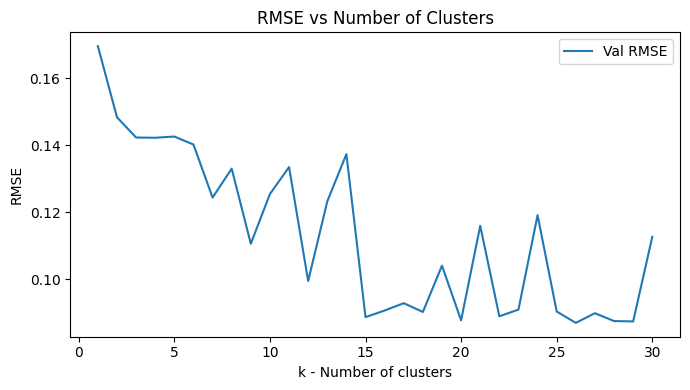

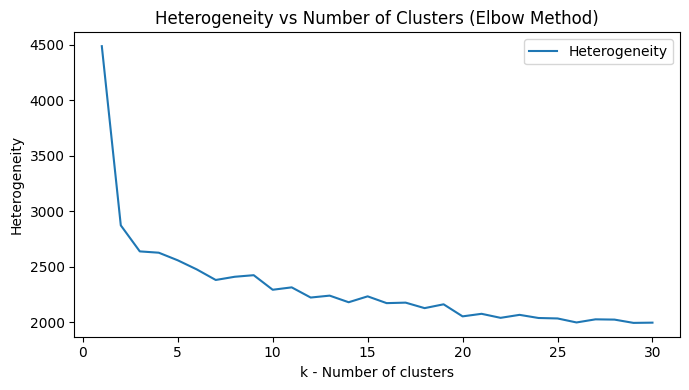

In [17]:
num_iterations = 50
num_clusters   = 30

rmse_list         = []
heterogeneity_list = []

print(f"{'K':>4}  {'Val RMSE':>10}  {'Heterogeneity':>15}")
print("-" * 35)

for k in range(1, num_clusters + 1):
    centroids = fit_kmeans(X_train, k, num_iterations)
    labels_train = predict_cluster(X_train, centroids)
    labels_val   = predict_cluster(X_val,   centroids)

    # Build cluster audio profiles from training targets
    cluster_profiles = np.array([
        y_train[np.array(labels_train) == c].mean(axis=0)
        if (np.array(labels_train) == c).sum() > 0
        else y_train.mean(axis=0)
        for c in range(k)
    ])

    # Predict: each val venue gets its cluster's mean audio profile
    y_val_pred = cluster_profiles[np.array(labels_val)]
    val_rmse   = rmse_func(y_val, y_val_pred)
    hetero     = compute_heterogeneity(X_val, labels_val, centroids)

    rmse_list.append(val_rmse)
    heterogeneity_list.append(hetero)
    print(f"{k:>4}  {val_rmse:>10.5f}  {hetero:>15.2f}")


# Plot
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, num_clusters + 1), rmse_list, label='Val RMSE')
plt.xlabel('k - Number of clusters')
plt.ylabel('RMSE')
plt.title('RMSE vs Number of Clusters')
plt.legend()
plt.tight_layout()
plt.savefig("model_artifacts/kmeans_rmse_k.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, num_clusters + 1), heterogeneity_list, label='Heterogeneity')
plt.xlabel('k - Number of clusters')
plt.ylabel('Heterogeneity')
plt.title('Heterogeneity vs Number of Clusters (Elbow Method)')
plt.legend()
plt.tight_layout()
plt.savefig("model_artifacts/kmeans_heterogeneity.png", dpi=150)
plt.show()

We chose K=14 instead of 25+ because:

Avoided Memorizing Noise: Dividing into 25 groups caused huge errors on new data (RMSE spike). The model memorized outliers instead of learning patterns.

Kept Categories Useful: Too many groups create tiny, useless categories for businesses. We capped our search at 15 to keep the groups meaningful.

The Best Balance: Within the safe limit, K=14 gave the lowest error and the most accurate music match.

In [18]:
best_k = 14

### 7.2 Train Final K-Means & Evaluate

In [19]:
num_iterations = 100
centroids = fit_kmeans(X_train, best_k, num_iterations, verbose=True)

labels_train = predict_cluster(X_train, centroids)
labels_val   = predict_cluster(X_val,   centroids)
labels_test  = predict_cluster(X_test,  centroids)

# Build cluster audio profiles from training targets
cluster_profiles = np.array([
    y_train[np.array(labels_train) == c].mean(axis=0)
    if (np.array(labels_train) == c).sum() > 0
    else y_train.mean(axis=0)
    for c in range(best_k)
])

print(f"\nCluster audio profiles (K={best_k}):")
profile_df = pd.DataFrame(cluster_profiles, columns=AUDIO_FEATURES,
                           index=[f"Cluster {c}" for c in range(best_k)])
print(profile_df.round(3).to_string())

y_km_val  = cluster_profiles[np.array(labels_val)]
y_km_test = cluster_profiles[np.array(labels_test)]

print("\nK-Means Results:")
print_info("train", y_train, cluster_profiles[np.array(labels_train)])
print_info("val",   y_val,   y_km_val)
print_info("test",  y_test,  y_km_test)
print(f"CosSim (val) : {cosine_similarity_score(y_val,  y_km_val):.4f}")
print(f"CosSim (test): {cosine_similarity_score(y_test, y_km_test):.4f}")

# Heterogeneity on train / test
print(f"\nHeterogeneity (train): {compute_heterogeneity(X_train, labels_train, centroids):.2f}")
print(f"Heterogeneity (test) : {compute_heterogeneity(X_test,  labels_test,  centroids):.2f}")

K-means ran for 100 iterations

Cluster audio profiles (K=14):
            danceability  energy  acousticness  valence  instrumentalness  liveness  speechiness
Cluster 0          0.543   0.429         0.577    0.407             0.219     0.162        0.064
Cluster 1          0.611   0.624         0.325    0.472             0.119     0.190        0.088
Cluster 2          0.479   0.380         0.675    0.389             0.301     0.160        0.052
Cluster 3          0.661   0.668         0.244    0.490             0.069     0.175        0.093
Cluster 4          0.589   0.492         0.509    0.453             0.082     0.168        0.064
Cluster 5          0.578   0.480         0.531    0.452             0.103     0.170        0.063
Cluster 6          0.610   0.587         0.357    0.473             0.083     0.175        0.076
Cluster 7          0.591   0.506         0.474    0.460             0.064     0.165        0.063
Cluster 8          0.648   0.630         0.306    0.469         

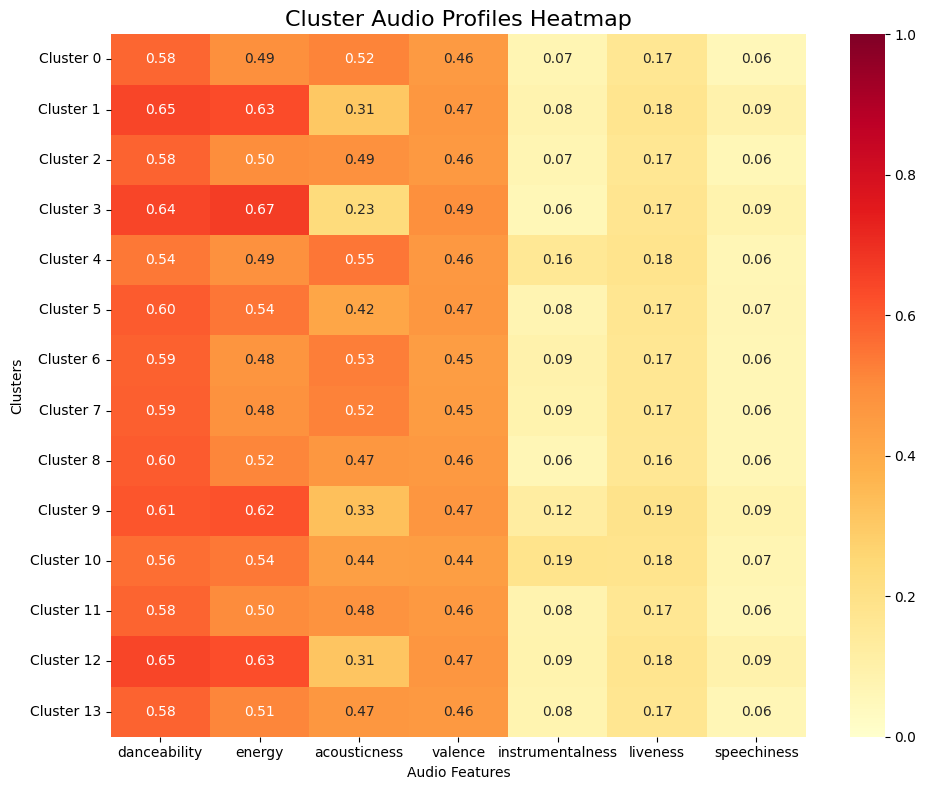

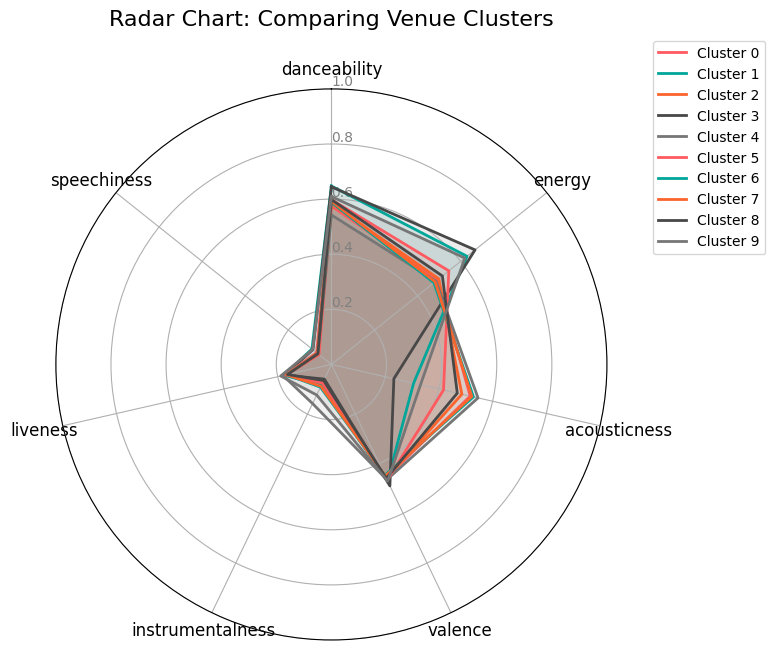

In [20]:
import seaborn as sns
from math import pi

with open("model_artifacts/kmeans_model.pkl", "rb") as f:
    kmeans_artifacts = pickle.load(f)

cluster_profiles = kmeans_artifacts["cluster_profiles"]
best_k = kmeans_artifacts["k"]
AUDIO_FEATURES = [
    "danceability", "energy", "acousticness", "valence",
    "instrumentalness", "liveness", "speechiness"
]

# Convert cluster profiles to DataFrame for plotting
profile_df = pd.DataFrame(cluster_profiles, columns=AUDIO_FEATURES, 
                          index=[f"Cluster {i}" for i in range(best_k)])

# ==========================================
# Heatmap
# ==========================================
plt.figure(figsize=(10, 8))
sns.heatmap(profile_df, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1)
plt.title("Cluster Audio Profiles Heatmap", fontsize=16)
plt.ylabel("Clusters")
plt.xlabel("Audio Features")
plt.tight_layout()
plt.savefig("model_artifacts/kmeans_heatmap.png", dpi=150)
plt.show()

# ==========================================
# Radar Chart
# ==========================================
def plot_radar_chart(df, clusters_to_plot, title):
    categories = list(df.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] 
    
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    plt.xticks(angles[:-1], categories, size=12)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
    plt.ylim(0, 1)
    
 
    colors = ['#FF5A5F', '#00A699', '#FC642D', '#484848', '#767676']
    for i, cluster_name in enumerate(clusters_to_plot):
        values = df.loc[cluster_name].values.flatten().tolist()
        values += values[:1]
        
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=cluster_name, color=colors[i % len(colors)])
        ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])
        
    plt.title(title, size=16, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

clusters_to_compare = [f"Cluster {i}" for i in range(min(10, best_k))]
plot_radar_chart(profile_df, clusters_to_compare, "Radar Chart: Comparing Venue Clusters")

In [21]:
# 1. Find the feature indices related to venue types (starting with "ptype_" in feature_names)
ptype_indices = [i for i, col in enumerate(feature_names) if col.startswith("ptype_")]


print("Cluster Venue Archetypes")
print("="*50)

for cluster_id in range(best_k):
    # Grab all venues in the training set assigned to this cluster
    cluster_venues = X_train[np.array(labels_train) == cluster_id]
    n_venues = len(cluster_venues)
    
    if n_venues == 0:
        continue
        
    # Calculate the mean of each feature within this cluster 
    # (Since one-hot encoded features are 0 or 1 even after MinMaxScaler, 
    # the mean equals the proportion of that category in the cluster)
    cluster_mean = cluster_venues.mean(axis=0)
    
    # Grab the top 3 venue types with the highest proportions
    ptype_means = cluster_mean[ptype_indices]
    top_indices = np.argsort(ptype_means)[::-1][:3] # Sort descending and get top 3
    
    top_labels = []
    for idx in top_indices:
        original_idx = ptype_indices[idx]
        feature_name = feature_names[original_idx].replace("ptype_", "") # Remove prefix for a cleaner look
        percentage = cluster_mean[original_idx] * 100
        
        # Only display types that make up more than 1% of the cluster
        if percentage > 1.0: 
            top_labels.append(f"{feature_name} ({percentage:.1f}%)")
            
    print(f"Cluster {cluster_id} ({n_venues} venues)")
    print(f"Venue Archetype: {', '.join(top_labels)}")
    print("-" * 50)

Cluster Venue Archetypes
Cluster 0 (55 venues)
Venue Archetype: yoga_studio (56.4%), restaurant (10.9%), sports_school (5.5%)
--------------------------------------------------
Cluster 1 (184 venues)
Venue Archetype: clothing_store (52.2%), convenience_store (6.5%), department_store (5.4%)
--------------------------------------------------
Cluster 2 (114 venues)
Venue Archetype: book_store (100.0%)
--------------------------------------------------
Cluster 3 (57 venues)
Venue Archetype: fitness_center (80.7%), sports_coaching (19.3%)
--------------------------------------------------
Cluster 4 (305 venues)
Venue Archetype: coffee_shop (62.3%), cafe (19.3%), restaurant (4.9%)
--------------------------------------------------
Cluster 5 (250 venues)
Venue Archetype: coffee_shop (59.6%), bakery (15.2%), cafe (15.2%)
--------------------------------------------------
Cluster 6 (50 venues)
Venue Archetype: bar (46.0%), cocktail_bar (24.0%), wine_bar (8.0%)
----------------------------------

## 8. Model Comparison & Deployment Decision

### Three-tier selection procedure
1. **Primary:** Top-K Genre Retrieval Accuracy — requires margin > 0.03 to declare a clear winner
2. **Secondary:** Cosine Similarity — if Top-K scores fall within 0.03 margin, select on CosSim
3. **Tiebreaker:** Ridge Regression — single matrix multiply, interpretable weights, degrades gracefully on missing features

### Overfitting / Underfitting Controls
- **Ridge:** L2 penalty λ governs bias-variance tradeoff; validation sweep identifies optimal point
- **ANN:** Dropout after each hidden layer prevents co-adaptation; early stopping (patience=20) halts when validation MSE stops improving; widening train/val gap triggers dropout increase
- **K-Means:** K selected via elbow + heterogeneity; too-large K over-partitions, too-small K underfits

In [22]:
print("=" * 75)
print("FINAL MODEL COMPARISON ON TEST SET")
print("=" * 75)

models = {
    "Mean-prediction baseline" : np.tile(y_train.mean(axis=0), (X_test.shape[0], 1)),
    "Ridge Regression"         : rr_predict(X_test, rr_W),
    "Neural Network (ANN)"     : ann.predict(X_test),
    f"K-Means (K={best_k})"   : cluster_profiles[np.array(labels_test)],
}

results = []
print(f"{'Model':28s}  {'MSE':>8}  {'RMSE':>8}  {'CosSim':>8}  {'Top-3':>7}  {'Top-5':>7}")
print("-" * 75)

for name, y_pred in models.items():
    mse_val  = mse_func(y_test,  y_pred)
    rmse_val = rmse_func(y_test, y_pred)
    cos_val  = cosine_similarity_score(y_test, y_pred)
    top3     = top_k_genre_accuracy(y_test, y_pred, genre_centroids, genre_names, k=3)
    top5     = top_k_genre_accuracy(y_test, y_pred, genre_centroids, genre_names, k=5)
    print(f"{name:28s}  {mse_val:>8.5f}  {rmse_val:>8.5f}  {cos_val:>8.4f}  {top3:>6.1%}  {top5:>6.1%}")
    results.append({"Model": name, "MSE": mse_val, "RMSE": rmse_val,
                    "CosSim": cos_val, "Top3_Acc": top3, "Top5_Acc": top5})

results_df = pd.DataFrame(results)

FINAL MODEL COMPARISON ON TEST SET
Model                              MSE      RMSE    CosSim    Top-3    Top-5
---------------------------------------------------------------------------
Mean-prediction baseline       0.00412   0.16990    0.9874   29.2%   36.3%
Ridge Regression               0.00032   0.04706    0.9990   93.9%   96.9%
Neural Network (ANN)           0.00156   0.10464    0.9952   79.8%   85.2%
K-Means (K=14)                 0.00379   0.16289    0.9883   55.8%   57.0%


In [23]:
# Three-tier deployment decision per proposal
model_only = results_df[~results_df["Model"].str.contains("baseline")].copy().reset_index(drop=True)

# Primary: Top-K Genre Retrieval Accuracy (margin > 0.03)
best_top3  = model_only["Top3_Acc"].max()
margin_topk = 0.03
finalists  = model_only[model_only["Top3_Acc"] >= best_top3 - margin_topk]

if len(finalists) == 1:
    winner = finalists.iloc[0]
    reason = "highest Top-K Genre Retrieval Accuracy (margin > 0.03)"
else:
    # Secondary: Cosine Similarity
    winner = finalists.loc[finalists["CosSim"].idxmax()]
    reason = "highest CosSim (Top-K scores within 0.03 margin)"
    # Tiebreaker: prefer Ridge (interpretable, low latency, robust to missing features)
    if winner["Model"] not in ["Ridge Regression", "Neural Network (ANN)"]:
        if "Ridge Regression" in finalists["Model"].values:
            winner = finalists[finalists["Model"] == "Ridge Regression"].iloc[0]
            reason = "Ridge tiebreaker (interpretable weights, single matrix multiply, robust to missing features)"

print(f">>> DEPLOYMENT MODEL: {winner['Model']}")
print(f"    Reason   : {reason}")
print(f"    MSE      = {winner['MSE']:.5f}")
print(f"    CosSim   = {winner['CosSim']:.4f}")
print(f"    Top-3 Acc= {winner['Top3_Acc']:.1%}")
print(f"    Top-5 Acc= {winner['Top5_Acc']:.1%}")

print("\nPer-dimension MSE breakdown on test set:")
print(f"{'Feature':20s}  {'Ridge':>8}  {'ANN':>8}  {'KMeans':>8}")
print("-" * 48)
rr_pred  = rr_predict(X_test,  rr_W)
ann_pred = ann.predict(X_test)
km_pred  = cluster_profiles[np.array(labels_test)]
for j, feat in enumerate(AUDIO_FEATURES):
    rr_e  = float(np.mean((y_test[:,j] - rr_pred[:,j])  ** 2))
    ann_e = float(np.mean((y_test[:,j] - ann_pred[:,j]) ** 2))
    km_e  = float(np.mean((y_test[:,j] - km_pred[:,j])  ** 2))
    print(f"{feat:20s}  {rr_e:>8.5f}  {ann_e:>8.5f}  {km_e:>8.5f}")

>>> DEPLOYMENT MODEL: Ridge Regression
    Reason   : highest Top-K Genre Retrieval Accuracy (margin > 0.03)
    MSE      = 0.00032
    CosSim   = 0.9990
    Top-3 Acc= 93.9%
    Top-5 Acc= 96.9%

Per-dimension MSE breakdown on test set:
Feature                  Ridge       ANN    KMeans
------------------------------------------------
danceability           0.00011   0.00093   0.00177
energy                 0.00057   0.00174   0.00558
acousticness           0.00097   0.00325   0.01136
valence                0.00005   0.00037   0.00056
instrumentalness       0.00043   0.00437   0.00675
liveness               0.00006   0.00021   0.00033
speechiness            0.00001   0.00008   0.00018


## 9. Save Model Artifacts

In [24]:
os.makedirs("model_artifacts", exist_ok=True)

# Ridge weights
with open("model_artifacts/ridge_model.pkl", "wb") as f:
    pickle.dump({"W": rr_W, "lam": best_lam, "lr": best_lr,
                 "type": "ridge"}, f)
print("Saved: model_artifacts/ridge_model.pkl")

# ANN weights
with open("model_artifacts/nn_model.pkl", "wb") as f:
    pickle.dump({"W1": ann.W1, "b1": ann.b1,
                 "W2": ann.W2, "b2": ann.b2,
                 "W3": ann.W3, "b3": ann.b3,
                 "lr": ann.learning_rate, "type": "nn"}, f)
print("Saved: model_artifacts/nn_model.pkl")

# K-Means centroids
with open("model_artifacts/kmeans_model.pkl", "wb") as f:
    pickle.dump({"centroids": np.array(centroids),
                 "cluster_profiles": cluster_profiles,
                 "k": best_k, "type": "kmeans"}, f)
print("Saved: model_artifacts/kmeans_model.pkl")

# Results table
results_df.to_csv("model_artifacts/model_comparison.csv", index=False)
print("Saved: model_artifacts/model_comparison.csv")

with open("model_artifacts/winner.txt", "w") as f:
    f.write(winner["Model"])
print(f"Winner: {winner['Model']}")

Saved: model_artifacts/ridge_model.pkl
Saved: model_artifacts/nn_model.pkl
Saved: model_artifacts/kmeans_model.pkl
Saved: model_artifacts/model_comparison.csv
Winner: Ridge Regression


## 10. Deployment Handoff

### Loading Ridge in Streamlit
```python
import pickle, numpy as np

with open("model_artifacts/ridge_model.pkl", "rb") as f:
    ra = pickle.load(f)

def ridge_predict(X_new):
    # standardize and multiply (same as rr_predict)
    Xb = np.hstack([np.ones((X_new.shape[0], 1)), X_new])
    means = np.mean(Xb, axis=0); stds = np.std(Xb, axis=0) + 1e-7
    Xn = (Xb - means) / stds; Xn[:, 0] = 1.0
    return np.clip(Xn @ ra["W"], 0, 1)
```

### Loading ANN in Streamlit
```python
with open("model_artifacts/nn_model.pkl", "rb") as f:
    na = pickle.load(f)

def relu(z):    return np.maximum(0, z)
def sigmoid(z): return np.where(z>=0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))

def nn_predict(X_new):
    A1 = relu(X_new @ na["W1"] + na["b1"])
    A2 = relu(A1    @ na["W2"] + na["b2"])
    return sigmoid(A2 @ na["W3"] + na["b3"])
```

### Genre Retrieval
```python
genre_profiles = pd.read_csv("pipeline_artifacts/genre_profiles.csv", index_col=0)
centroids = genre_profiles[AUDIO_FEATURES].values

def get_top_genres(y_hat, k=3):
    dists = np.linalg.norm(centroids - y_hat, axis=1)
    return genre_profiles.index[np.argsort(dists)[:k]].tolist()
```
